In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from pathlib import Path

In [2]:
project_path = Path("/Users/irinafendley/Projects/Loan_Default")

df = pd.read_csv(
    project_path / "data/processed/loan_clean.csv"
)

In [3]:
model = joblib.load(
    project_path / "data/models/logistic_regression.pkl"
)

In [4]:
df_model = df.drop("LoanID", axis=1)

X = df_model.drop("Default", axis=1)

X = pd.get_dummies(
    X,
    drop_first=True
)

In [5]:
df["Probability_of_Default"] = model.predict_proba(X)[:, 1]

In [6]:
df[
    [
        "LoanAmount",
        "Probability_of_Default",
        "Default"
    ]
].head(10)

,LoanAmount,Probability_of_Default,Default
0,50587,0.207341,0
1,124440,0.159942,0
2,129188,0.641189,1
3,44799,0.574788,0
4,9139,0.348577,0
5,90448,0.810885,1
6,177025,0.461559,0
7,155511,0.178855,0
8,92357,0.614089,1
9,228510,0.339719,0


In [7]:
df["Expected_Loss"] = (
    df["Probability_of_Default"]
    *
    df["LoanAmount"]
)

In [8]:
df["Risk_Segment"] = pd.qcut(
    df["Probability_of_Default"],
    q=3,
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

In [9]:
risk_summary = (
    df
    .groupby("Risk_Segment")
    .agg(
        Borrowers=("LoanAmount", "count"),
        Total_Loans=("LoanAmount", "sum"),
        Expected_Loss=("Expected_Loss", "sum")
    )
)

risk_summary["Total_Loans"] = risk_summary["Total_Loans"].round(0)
risk_summary["Expected_Loss"] = risk_summary["Expected_Loss"].round(0)

print(risk_summary)

              Borrowers  Total_Loans  Expected_Loss
Risk_Segment                                       
Low Risk          85116   8598398873   1.806831e+09
Medium Risk       85115  10877555050   4.518725e+09
High Risk         85116  13100926649   8.808618e+09


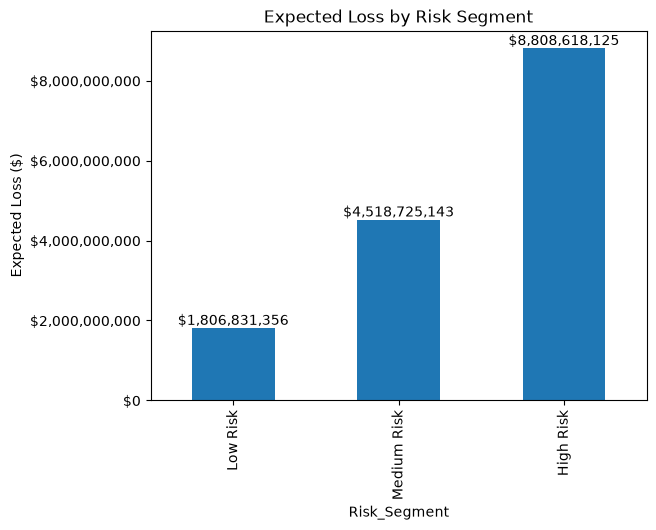


Risk Segment Summary
              Borrowers  Total_Loans  Expected_Loss
Risk_Segment                                       
Low Risk          85116   8598398873   1.806831e+09
Medium Risk       85115  10877555050   4.518725e+09
High Risk         85116  13100926649   8.808618e+09


In [10]:


ax = risk_summary["Expected_Loss"].plot(
    kind="bar"
)

ax.yaxis.set_major_formatter(
    mtick.StrMethodFormatter('${x:,.0f}')
)

for p in ax.patches:
    ax.annotate(
        f'${p.get_height():,.0f}',
        (p.get_x() + p.get_width() / 2,
         p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title("Expected Loss by Risk Segment")
plt.ylabel("Expected Loss ($)")
plt.show()

print("\nRisk Segment Summary")
print(risk_summary)

In [18]:
high_risk = df[
    df["Risk_Segment"] == "High Risk"
].copy()

print("High-risk borrowers:")
print(len(high_risk))

High-risk borrowers:
85116


In [21]:
additional_clients = int(
    len(high_risk) * 0.10
)

scenario_clients = (
    high_risk
    .sort_values(
        "Probability_of_Default",
        ascending=False
    )
    .head(additional_clients)
)

In [22]:
expected_defaults = (
    scenario_clients["Probability_of_Default"]
    .sum()
)

print(
    "Expected Additional Defaults:",
    round(expected_defaults)
)

Expected Additional Defaults: 7253


In [23]:
print(
    f"Additional approvals: {extra_count}"
)

print(
    f"Expected additional defaults: {extra_expected_defaults:.0f}"
)

print(
    f"Expected additional loss: ${extra_expected_loss:,.0f}"
)

Additional approvals: 8511
Expected additional defaults: 7253
Expected additional loss: $1,337,745,320


In [24]:
scenario_table = pd.DataFrame({
    "Metric": [
        "Additional Approvals",
        "Expected Defaults",
        "Expected Loss"
    ],
    "Value": [
        extra_count,
        round(extra_expected_defaults),
        round(extra_expected_loss)
    ]
})

scenario_table

,Metric,Value
0,Additional Approvals,8511
1,Expected Defaults,7253
2,Expected Loss,1337745320


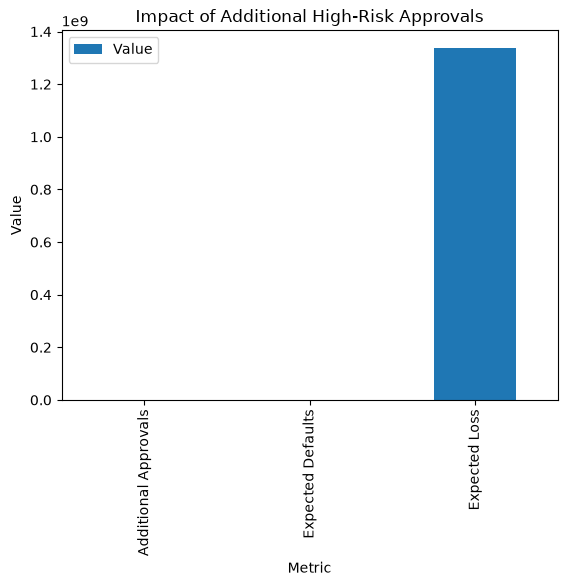

In [25]:
scenario_table.plot(
    x="Metric",
    y="Value",
    kind="bar"
)

plt.title(
    "Impact of Additional High-Risk Approvals"
)

plt.ylabel(
    "Value"
)

plt.show()

In [26]:
additional_loss = (
    scenario_clients["Expected_Loss"]
    .sum()
)

print(
    f"Expected Additional Loss: ${additional_loss:,.0f}"
)

Expected Additional Loss: $1,337,745,320


In [28]:
additional_loans = (
    scenario_clients["LoanAmount"]
    .sum()
)

print(
    f"Additional Approved Loans: ${additional_loans:,.0f}"
)

Additional Approved Loans: $1,567,000,892


In [27]:
expected_defaults = (
    scenario_clients["Probability_of_Default"]
    .sum()
)

print(
    "Expected Additional Defaults:",
    round(expected_defaults)
)

Expected Additional Defaults: 7253


In [29]:
simulation_results = pd.DataFrame({
    "Metric": [
        "Additional Borrowers",
        "Additional Loan Volume",
        "Expected Defaults",
        "Expected Loss"
    ],
    "Value": [
        len(scenario_clients),
        additional_loans,
        round(expected_defaults),
        additional_loss
    ]
})

simulation_results

,Metric,Value
0,Additional Borrowers,8.511000e+03
1,Additional Loan Volume,1.567001e+09
2,Expected Defaults,7.253000e+03
3,Expected Loss,1.337745e+09


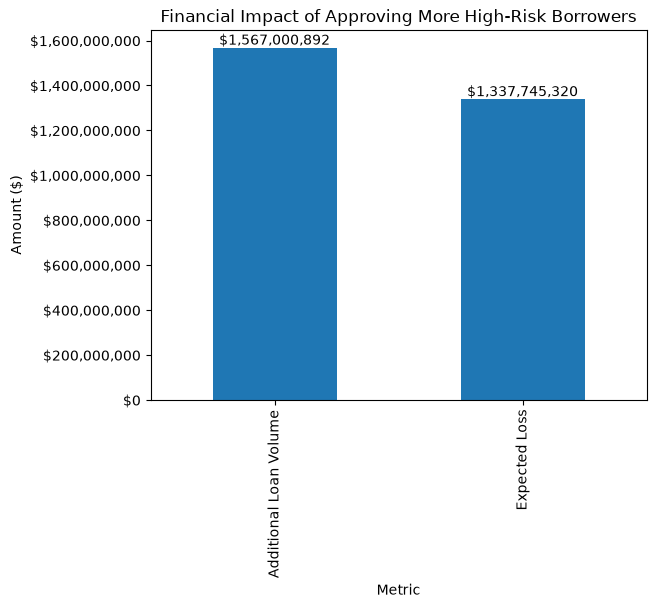

In [30]:

plot_df = simulation_results[
    simulation_results["Metric"].isin(
        [
            "Additional Loan Volume",
            "Expected Loss"
        ]
    )
]

ax = plot_df.plot(
    x="Metric",
    y="Value",
    kind="bar",
    legend=False
)

ax.yaxis.set_major_formatter(
    mtick.StrMethodFormatter('${x:,.0f}')
)

for p in ax.patches:
    ax.annotate(
        f'${p.get_height():,.0f}',
        (
            p.get_x() + p.get_width()/2,
            p.get_height()
        ),
        ha="center",
        va="bottom"
    )

plt.title(
    "Financial Impact of Approving More High-Risk Borrowers"
)

plt.ylabel("Amount ($)")
plt.show()